Library Imports

In [1]:
from collections import Counter
import pandas as pd
from pathlib import Path
import random
import xml.etree.ElementTree as ET
from scipy.special.cython_special import pdtr
import matplotlib.pyplot as plt
import umap
from sklearn.preprocessing import StandardScaler

damage_type = ["D00", "D01", "D10", "D11", "D20", "D40", "D43", "D44"]
# damage_label =

/home/student/PycharmProjects/road_damage/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


China Exploration

In [40]:
#China_Drone - Processiong XML Files
drone_path = Path("/nfshome/data/China_Drone/train")

drone_xml_dir = drone_path / "annotations" / "xmls"
drone_xml_files = sorted(drone_xml_dir.glob("*.xml"))

all_drone_xmls =[]

# Object Extraction: https://lxml.de/tutorial.html
for file in drone_xml_files:
    tree = ET.parse(file)
    root = tree.getroot()
    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)
    depth = int(root.find("size/depth").text)

    for obj in root.findall("object"):
        cls = obj.find("name").text
        pose = obj.find("pose").text
        truncated = int(obj.find("truncated").text)
        difficult = int(obj.find("difficult").text)
        bnd = obj.find("bndbox")
        xmin = int(bnd.find("xmin").text)
        ymin = int(bnd.find("ymin").text)
        xmax = int(bnd.find("xmax").text)
        ymax = int(bnd.find("ymax").text)

        all_drone_xmls.append(
            {
                "file": filename,
                "width": width,
                "height": height,
                "depth": depth,
                "class": cls,
                "pose": pose,
                "truncated": truncated,
                "difficult": difficult,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            }
        )

#China_Drone - Processing Image Files
drone_image_dir = drone_path / "images"
drone_images = list(drone_image_dir.glob("*.jpg"))

print(" "*20, "China_Drone Overview")
print(f"Number of Drone objects: {len(all_drone_xmls)}")
print("\nAnnotation Example:")
drone_xml_files = list({d["file"] for d in all_drone_xmls})
rand_file = random.choice(drone_xml_files)
drone_objs = [d for d in all_drone_xmls if d["file"] == rand_file]
for o in drone_objs:
    print(o)
print(f"\nNumber of Drone images: {len(drone_images)}")

                     China_Drone Overview
Number of Drone objects: 3840

Annotation Example:
{'file': 'China_Drone_000492.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D00', 'pose': 'Unspecified', 'truncated': 0, 'difficult': 0, 'xmin': 141, 'ymin': 65, 'xmax': 168, 'ymax': 227}

Number of Drone images: 2401


In [37]:
#China_MotorBike Train Directory - Processing XML Files
mb_train_path = Path("/nfshome/data/China_MotorBike/train")

mb_train_xml_dir = mb_train_path / "annotations" / "xmls"
mb_train_xml_files = sorted(mb_train_xml_dir.glob("*.xml"))

all_mb_train_xmls =[]
# Object Extraction: https://lxml.de/tutorial.html
for file in mb_train_xml_files:
    tree = ET.parse(file)
    root = tree.getroot()
    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)
    depth = int(root.find("size/depth").text)

    for obj in root.findall("object"):
        cls = obj.find("name").text
        pose = obj.find("pose").text
        truncated = int(obj.find("truncated").text)
        difficult = int(obj.find("difficult").text)
        bnd = obj.find("bndbox")
        xmin = int(bnd.find("xmin").text)
        ymin = int(bnd.find("ymin").text)
        xmax = int(bnd.find("xmax").text)
        ymax = int(bnd.find("ymax").text)

        all_mb_train_xmls.append(
            {
                "file": filename,
                "width": width,
                "height": height,
                "depth": depth,
                "class": cls,
                "pose": pose,
                "truncated": truncated,
                "difficult": difficult,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            }
        )

# China_MotorBike Train Directory - Processing Image Files
mb_train_image_dir = mb_train_path / "images"
mb_train_images = list(mb_train_image_dir.glob("*.jpg"))

#China_Motorbike Test Directory - Processing Image Files
mb_test_path = Path("/nfshome/data/China_MotorBike/test")
mb_test_image_dir = mb_test_path / "images"
mb_test_images = list(mb_test_image_dir.glob("*.jpg"))

print(" "*20, "China_MotorBike Overview")
print(f"Number of MotorBike objects: {len(all_mb_train_xmls)}")
print("\nAnnotation Example:")
mb_train_files = list({d["file"] for d in all_mb_train_xmls})
rand_file = random.choice(mb_train_files)
mb_train_objs = [d for d in all_mb_train_xmls if d["file"] == rand_file]
for o in mb_train_objs:
    print(o)
print(f"\nNumber of MotorBike images in train directory: {len(mb_train_images)}")
print(f"Number of MotorBike images in test directory: {len(mb_test_images)}")
print(f"Total MotorBike images: {(len(mb_train_images) + len(mb_test_images))}")


                     China_MotorBike Overview
Number of MotorBike objects: 4927

Annotation Example:
{'file': 'China_MotorBike_000911.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D10', 'pose': 'Unspecified', 'truncated': 1, 'difficult': 0, 'xmin': 26, 'ymin': 143, 'xmax': 512, 'ymax': 211}
{'file': 'China_MotorBike_000911.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D00', 'pose': 'Unspecified', 'truncated': 1, 'difficult': 0, 'xmin': 200, 'ymin': 9, 'xmax': 224, 'ymax': 512}
{'file': 'China_MotorBike_000911.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D10', 'pose': 'Unspecified', 'truncated': 0, 'difficult': 0, 'xmin': 356, 'ymin': 53, 'xmax': 468, 'ymax': 76}
{'file': 'China_MotorBike_000911.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D00', 'pose': 'Unspecified', 'truncated': 1, 'difficult': 0, 'xmin': 429, 'ymin': 1, 'xmax': 470, 'ymax': 56}
{'file': 'China_MotorBike_000911.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D00',

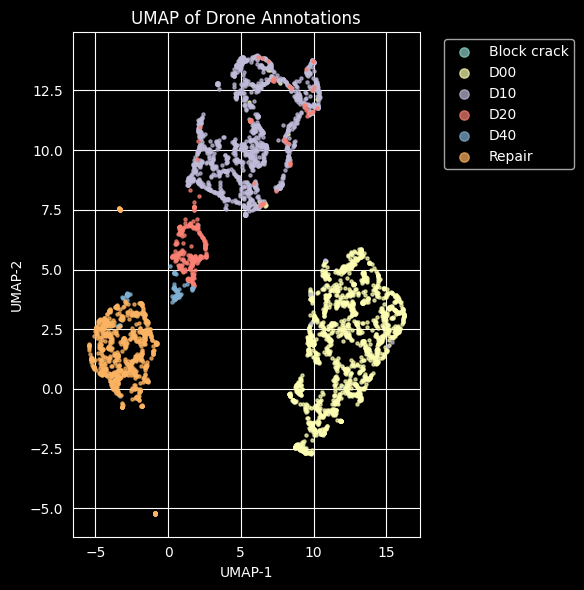

Clusters show D00 is perpendicular from the rest of the classes.
D10 and D20 have similar locations and sizes.
With Repair more closely related to D20, D40, and D10


In [6]:
# Visualization for China_Drone and China_MotorBike
df = pd.DataFrame(all_drone_xmls)

df["box_w"] = df["xmax"] - df["xmin"]
df["box_h"] = df["ymax"] - df["ymin"]
df["range_xmin"] = df["xmin"] / df["width"]
df["range_ymin"] = df["ymin"] / df["height"]
df["range_box_w"] = df["box_w"] / df["width"]
df["range_box_h"] = df["box_h"] / df["height"]

class_convert_id = {c: i for i, c in enumerate(sorted(df["class"].unique()))}
df["class_id"] = df["class"].map(class_convert_id)

features = df[["range_xmin", "range_ymin", "range_box_w", "range_box_h", "class_id"]].values

scaled = StandardScaler().fit_transform(features)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2
)

embedding = reducer.fit_transform(scaled)
df["umap_x"] = embedding[:, 0]
df["umap_y"] = embedding[:, 1]

plt.figure(figsize=(6, 6))
for cls, sub in df.groupby("class"):
    plt.scatter(sub["umap_x"], sub["umap_y"], s=5, alpha=0.7, label=cls)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of Drone Annotations")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("Clusters show D00 is perpendicular from the rest of the classes.\nD10 and D20 have similar locations and sizes.\nWith Repair more closely related to D20, D40, and D10")

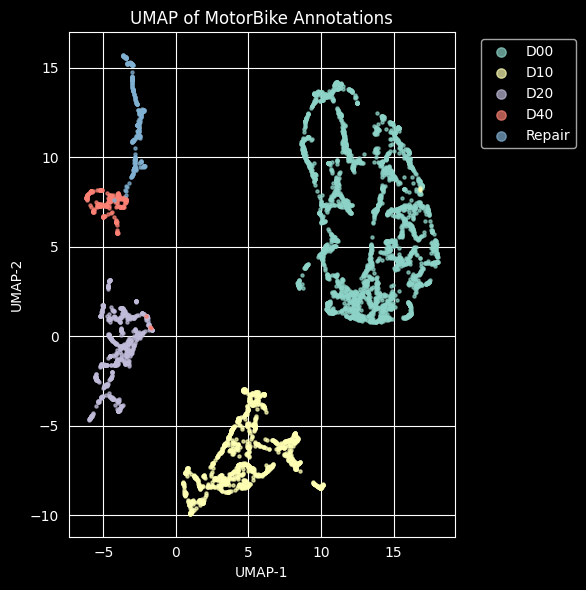

Clusters show D00 and D10 greatly differ from the other classes. 
D40 and Repair have similar locations and sizes. With D20 having similar locations and sizes as D40



In [7]:
# Visualization for China_Drone and China_MotorBike
df = pd.DataFrame(all_mb_train_xmls)

df["box_w"] = df["xmax"] - df["xmin"]
df["box_h"] = df["ymax"] - df["ymin"]
df["range_xmin"] = df["xmin"] / df["width"]
df["range_ymin"] = df["ymin"] / df["height"]
df["range_box_w"] = df["box_w"] / df["width"]
df["range_box_h"] = df["box_h"] / df["height"]

class_convert_id = {c: i for i, c in enumerate(sorted(df["class"].unique()))}
df["class_id"] = df["class"].map(class_convert_id)

features = df[["range_xmin", "range_ymin", "range_box_w", "range_box_h", "class_id"]].values

scaled = StandardScaler().fit_transform(features)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2
)

embedding = reducer.fit_transform(scaled)
df["umap_x"] = embedding[:, 0]
df["umap_y"] = embedding[:, 1]

plt.figure(figsize=(6, 6))
for cls, sub in df.groupby("class"):
    plt.scatter(sub["umap_x"], sub["umap_y"], s=5, alpha=0.7, label=cls)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of MotorBike Annotations")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("Clusters show D00 and D10 greatly differ from the other classes. \nD40 and Repair have similar locations and sizes. With D20 having similar locations and sizes as D40\n")

In [ ]:
Czech Exploration

In [8]:
#Czech Train Directory - Processiong XML Files
czech_train_path = Path("/nfshome/data/Czech/train")

czech_train_xml_dir = czech_train_path / "annotations" / "xmls"
czech_train_xml_files = sorted(czech_train_xml_dir.glob("*.xml"))

all_czech_train_xmls =[]

# Object Extraction: https://lxml.de/tutorial.html
for file in czech_train_xml_files:
    tree = ET.parse(file)
    root = tree.getroot()
    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)
    depth = int(root.find("size/depth").text)

    for obj in root.findall("object"):
        cls = obj.find("name").text
        pose = obj.findtext("pose", default="uknown")

        #truncated = int(obj.findtext("truncated",default="uknown"))
        truncated = int(root.find('truncated').text) if root.find('truncated') is not None else None,
        #difficult = int(obj.find("difficult").text)
        difficult = int(root.find("difficult").text) if root.find ("difficult") is not None else None,

        bnd = obj.find("bndbox")
        xmin = int(bnd.find("xmin").text)
        ymin = int(bnd.find("ymin").text)
        xmax = int(bnd.find("xmax").text)
        ymax = int(bnd.find("ymax").text)

        all_czech_train_xmls.append(
            {
                "file": filename,
                "width": width,
                "height": height,
                "depth": depth,
                "class": cls,
                "pose": pose,
                "truncated": truncated,
                "difficult": difficult,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            }
        )

#Czech Train Directory - Processing Image Files
czech_train_image_dir = czech_train_path / "images"
czech_train_images = list(czech_train_image_dir.glob("*.jpg"))

#Czech Test Directory - Processing Image Files
czech_test_path = Path("/nfshome/data/Czech/test")
czech_test_image_dir = czech_test_path / "images"
czech_test_images = list(czech_test_image_dir.glob("*.jpg"))

print(" "*20, "Czech Overview")
print(f"Number of Czech objects: {len(all_czech_train_xmls)}")
print("\nAnnotation Example:")
czech_train_xml_files = list({d["file"] for d in all_czech_train_xmls})
rand_file = random.choice(czech_train_xml_files)
czech_train_objs = [d for d in all_czech_train_xmls if d["file"] == rand_file]
for o in czech_train_objs:
    print(o)

print(f"\nNumber of Czech images in train directory: {len(czech_train_images)}")
print(f"Number of Czech images in test directory: {len(czech_test_images)}")
print(f"Total Czech images: {(len(czech_train_images) + len(czech_test_images))}")

                     Czech Overview
Number of Czech objects: 1745

Annotation Example:
{'file': 'Czech_001943.jpg', 'width': 600, 'height': 600, 'depth': 3, 'class': 'D00', 'pose': 'uknown', 'truncated': (None,), 'difficult': (None,), 'xmin': 299, 'ymin': 370, 'xmax': 359, 'ymax': 442}

Number of Czech images in train directory: 2829
Number of Czech images in test directory: 709
Total Czech images: 3538


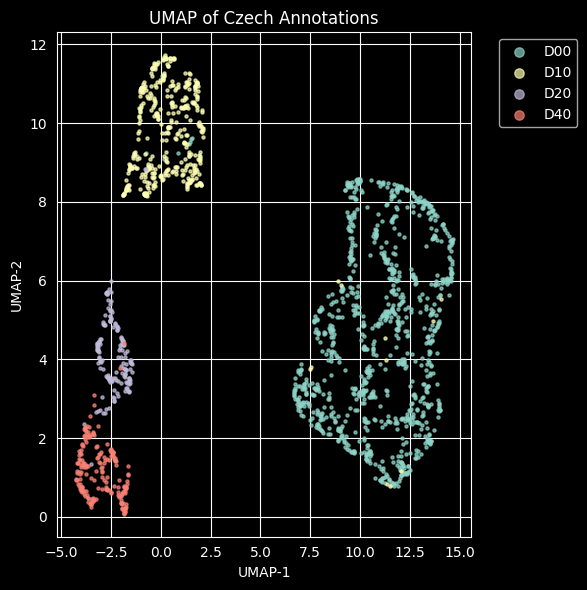

In [9]:
# Visualization for Czech
df = pd.DataFrame(all_czech_train_xmls)

df["box_w"] = df["xmax"] - df["xmin"]
df["box_h"] = df["ymax"] - df["ymin"]
df["range_xmin"] = df["xmin"] / df["width"]
df["range_ymin"] = df["ymin"] / df["height"]
df["range_box_w"] = df["box_w"] / df["width"]
df["range_box_h"] = df["box_h"] / df["height"]

class_convert_id = {c: i for i, c in enumerate(sorted(df["class"].unique()))}
df["class_id"] = df["class"].map(class_convert_id)

features = df[["range_xmin", "range_ymin", "range_box_w", "range_box_h", "class_id"]].values

scaled = StandardScaler().fit_transform(features)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2
)

embedding = reducer.fit_transform(scaled)
df["umap_x"] = embedding[:, 0]
df["umap_y"] = embedding[:, 1]

plt.figure(figsize=(6, 6))
for cls, sub in df.groupby("class"):
    plt.scatter(sub["umap_x"], sub["umap_y"], s=5, alpha=0.7, label=cls)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of Czech Annotations")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("")

India Exploration

In [10]:
#India Train Directory - Processing XML Files
india_train_path = Path("/nfshome/data/India/train")

india_train_xml_dir = india_train_path / "annotations" / "xmls"
india_train_xml_files = sorted(india_train_xml_dir.glob("*.xml"))

all_india_train_xmls =[]

# Object Extraction: https://lxml.de/tutorial.html
for file in india_train_xml_files:
    tree = ET.parse(file)
    root = tree.getroot()
    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)
    depth = int(root.find("size/depth").text)

    for obj in root.findall("object"):
        cls = obj.find("name").text
        pose = obj.findtext("pose", default="uknown")

        #truncated = int(obj.findtext("truncated",default="uknown"))
        truncated = int(root.find('truncated').text) if root.find('truncated') is not None else None,
        #difficult = int(obj.find("difficult").text)
        difficult = int(root.find("difficult").text) if root.find ("difficult") is not None else None,

        bnd = obj.find("bndbox")
        xmin = int(bnd.find("xmin").text)
        ymin = int(bnd.find("ymin").text)
        xmax = int(bnd.find("xmax").text)
        ymax = int(bnd.find("ymax").text)

        all_india_train_xmls.append(
            {
                "file": filename,
                "width": width,
                "height": height,
                "depth": depth,
                "class": cls,
                "pose": pose,
                "truncated": truncated,
                "difficult": difficult,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            }
        )

#india Train Directory - Processing Image Files
india_train_image_dir = india_train_path / "images"
india_train_images = list(india_train_image_dir.glob("*.jpg"))

#india Test Directory - Processing Image Files
india_test_path = Path("/nfshome/data/India/test")
india_test_image_dir = india_test_path / "images"
india_test_images = list(india_test_image_dir.glob("*.jpg"))

print(" "*20, "India Overview")
print(f"Number of india objects: {len(all_india_train_xmls)}")
print("\nAnnotation Example:")
india_train_xml_files = list({d["file"] for d in all_india_train_xmls})
rand_file = random.choice(india_train_xml_files)
india_train_objs = [d for d in all_india_train_xmls if d["file"] == rand_file]
for o in india_train_objs:
    print(o)

print(f"\nNumber of India images in train directory: {len(india_train_images)}")
print(f"Number of India images in test directory: {len(india_test_images)}")
print(f"Total India images: {(len(india_train_images) + len(india_test_images))}")

                     India Overview
Number of india objects: 8203

Annotation Example:
{'file': 'India_001098.jpg', 'width': 720, 'height': 720, 'depth': 3, 'class': 'D20', 'pose': 'Unspecified', 'truncated': (None,), 'difficult': (None,), 'xmin': 143, 'ymin': 458, 'xmax': 438, 'ymax': 666}

Number of India images in train directory: 7706
Number of India images in test directory: 1959
Total India images: 9665


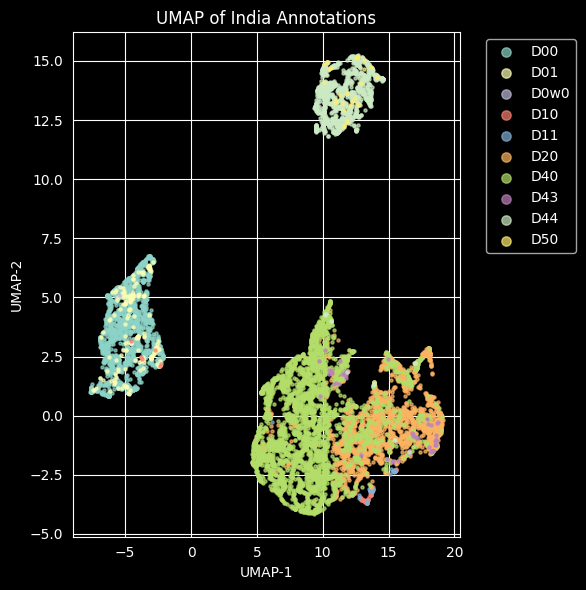

In [11]:
# Visualization for India
df = pd.DataFrame(all_india_train_xmls)

df["box_w"] = df["xmax"] - df["xmin"]
df["box_h"] = df["ymax"] - df["ymin"]
df["range_xmin"] = df["xmin"] / df["width"]
df["range_ymin"] = df["ymin"] / df["height"]
df["range_box_w"] = df["box_w"] / df["width"]
df["range_box_h"] = df["box_h"] / df["height"]

class_convert_id = {c: i for i, c in enumerate(sorted(df["class"].unique()))}
df["class_id"] = df["class"].map(class_convert_id)

features = df[["range_xmin", "range_ymin", "range_box_w", "range_box_h", "class_id"]].values

scaled = StandardScaler().fit_transform(features)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2
)

embedding = reducer.fit_transform(scaled)
df["umap_x"] = embedding[:, 0]
df["umap_y"] = embedding[:, 1]

plt.figure(figsize=(6, 6))
for cls, sub in df.groupby("class"):
    plt.scatter(sub["umap_x"], sub["umap_y"], s=5, alpha=0.7, label=cls)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of India Annotations")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("")

Japan Exploration

In [12]:
#Japan Train Directory - Processing XML Files
japan_train_path = Path("/nfshome/data/Japan/train")

japan_train_xml_dir = japan_train_path / "annotations" / "xmls"
japan_train_xml_files = sorted(japan_train_xml_dir.glob("*.xml"))

all_japan_train_xmls =[]

# Object Extraction: https://lxml.de/tutorial.html
for file in japan_train_xml_files:
    tree = ET.parse(file)
    root = tree.getroot()
    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)
    depth = int(root.find("size/depth").text)if root.find("size/depth") is not None else None
    for obj in root.findall("object"):
        cls = obj.find("name").text
        pose = obj.findtext("pose", default="uknown")

        #truncated = int(obj.findtext("truncated",default="uknown"))
        truncated = int(root.find("truncated").text) if root.find("truncated") is not None else None,
        #difficult = int(obj.find("difficult").text)
        difficult = int(root.find("difficult").text) if root.find ("difficult") is not None else None,

        bnd = obj.find("bndbox")
        xmin = int(bnd.find("xmin").text)
        ymin = int(bnd.find("ymin").text)
        xmax = int(bnd.find("xmax").text)
        ymax = int(bnd.find("ymax").text)

        all_japan_train_xmls.append(
            {
                "file": filename,
                "width": width,
                "height": height,
                "depth": depth,
                "class": cls,
                "pose": pose,
                "truncated": truncated,
                "difficult": difficult,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            }
        )

#Japan Train Directory - Processing Image Files
japan_train_image_dir = japan_train_path / "images"
japan_train_images = list(japan_train_image_dir.glob("*.jpg"))

#Japan Test Directory - Processing Image Files
japan_test_path = Path("/nfshome/data/Japan/test")
japan_test_image_dir = japan_test_path / "images"
japan_test_images = list(japan_test_image_dir.glob("*.jpg"))

print(" "*20, "Japan Overview")
print(f"Number of Japan objects: {len(all_japan_train_xmls)}")
print("\nAnnotation Example:")
japan_train_xml_files = list({d["file"] for d in all_japan_train_xmls})
rand_file = random.choice(japan_train_xml_files)
japan_train_objs = [d for d in all_japan_train_xmls if d["file"] == rand_file]
for o in japan_train_objs:
    print(o)

print(f"\nNumber of Japan images in train directory: {len(japan_train_images)}")
print(f"Number of Japan images in test directory: {len(japan_test_images)}")
print(f"Total Japan images: {(len(japan_train_images) + len(japan_test_images))}")

                     Japan Overview
Number of Japan objects: 24754

Annotation Example:
{'file': 'Japan_002503.jpg', 'width': 600, 'height': 600, 'depth': 3, 'class': 'D44', 'pose': 'Unspecified', 'truncated': (None,), 'difficult': (None,), 'xmin': 305, 'ymin': 216, 'xmax': 387, 'ymax': 270}

Number of Japan images in train directory: 10506
Number of Japan images in test directory: 2627
Total Japan images: 13133


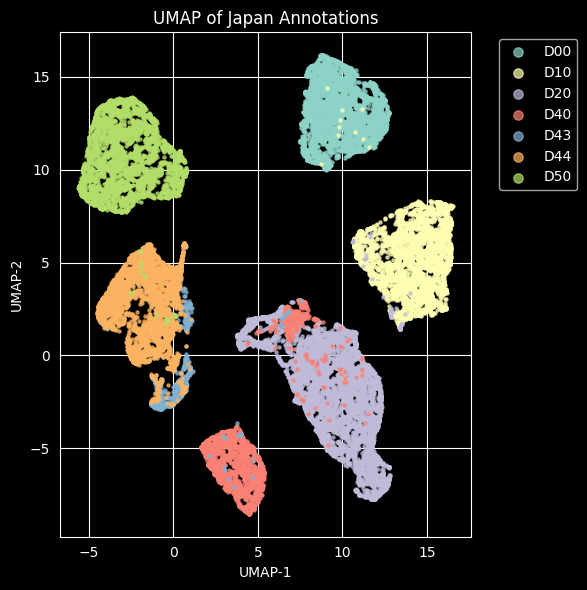

In [13]:
# Visualization for Japan
df = pd.DataFrame(all_japan_train_xmls)

df["box_w"] = df["xmax"] - df["xmin"]
df["box_h"] = df["ymax"] - df["ymin"]
df["range_xmin"] = df["xmin"] / df["width"]
df["range_ymin"] = df["ymin"] / df["height"]
df["range_box_w"] = df["box_w"] / df["width"]
df["range_box_h"] = df["box_h"] / df["height"]

class_convert_id = {c: i for i, c in enumerate(sorted(df["class"].unique()))}
df["class_id"] = df["class"].map(class_convert_id)

features = df[["range_xmin", "range_ymin", "range_box_w", "range_box_h", "class_id"]].values

scaled = StandardScaler().fit_transform(features)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2
)

embedding = reducer.fit_transform(scaled)
df["umap_x"] = embedding[:, 0]
df["umap_y"] = embedding[:, 1]

plt.figure(figsize=(6, 6))
for cls, sub in df.groupby("class"):
    plt.scatter(sub["umap_x"], sub["umap_y"], s=5, alpha=0.7, label=cls)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of Japan Annotations")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("")

In [ ]:
Norway Exploration

In [14]:
#Norway Train Directory - Processing XML Files
norway_train_path = Path("/nfshome/data/Norway/train")

norway_train_xml_dir = norway_train_path / "annotations" / "xmls"
norway_train_xml_files = sorted(norway_train_xml_dir.glob("*.xml"))

all_norway_train_xmls =[]

# Object Extraction: https://lxml.de/tutorial.html
for file in norway_train_xml_files:
    tree = ET.parse(file)
    root = tree.getroot()
    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)
    depth_elem = root.find("size/depth")
    depth = int(depth_elem.text)if depth_elem is not None and depth_elem.text else None
    for obj in root.findall("object"):
        cls = obj.find("name").text
        pose = obj.findtext("pose", default="uknown")

        #truncated = int(obj.findtext("truncated",default="uknown"))
        truncated = int(root.find("truncated").text) if root.find("truncated") is not None else None,
        #difficult = int(obj.find("difficult").text)
        difficult = int(root.find("difficult").text) if root.find ("difficult") is not None else None,

        bnd = obj.find("bndbox")
        xmin = float(bnd.find("xmin").text)
        ymin = float(bnd.find("ymin").text)
        xmax = float(bnd.find("xmax").text)
        ymax = float(bnd.find("ymax").text)

        all_norway_train_xmls.append(
            {
                "file": filename,
                "width": width,
                "height": height,
                "depth": depth,
                "class": cls,
                "pose": pose,
                "truncated": truncated,
                "difficult": difficult,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            }
        )

# Norway Train Directory - Processing Image Files
norway_train_image_dir = norway_train_path / "images"
norway_train_images = list(norway_train_image_dir.glob("*.jpg"))

# Norway Test Directory - Processing Image Files
norway_test_path = Path("/nfshome/data/Norway/test")
norway_test_image_dir = norway_test_path / "images"
norway_test_images = list(norway_test_image_dir.glob("*.jpg"))

print(" "*20, "Norway Overview")
print(f"Number of Norway objects: {len(all_norway_train_xmls)}")
print("\nAnnotation Example:")
norway_train_xml_files = list({d["file"] for d in all_norway_train_xmls})
rand_file = random.choice(norway_train_xml_files)
norway_train_objs = [d for d in all_norway_train_xmls if d["file"] == rand_file]
for o in norway_train_objs:
    print(o)

print(f"\nNumber of Norway images in train directory: {len(norway_train_images)}")
print(f"Number of Norway images in test directory: {len(norway_test_images)}")
print(f"Total Norway images: {(len(norway_train_images) + len(norway_test_images))}")

                     Norway Overview
Number of Norway objects: 11229

Annotation Example:
{'file': 'Norway_005914.jpg', 'width': 4040, 'height': 2035, 'depth': None, 'class': 'D00', 'pose': 'uknown', 'truncated': (None,), 'difficult': (None,), 'xmin': 1.77, 'ymin': 1476.2, 'xmax': 179.41, 'ymax': 1564.11}
{'file': 'Norway_005914.jpg', 'width': 4040, 'height': 2035, 'depth': None, 'class': 'D00', 'pose': 'uknown', 'truncated': (None,), 'difficult': (None,), 'xmin': 257.2, 'ymin': 1157.55, 'xmax': 770.95, 'ymax': 1415.4}

Number of Norway images in train directory: 8161
Number of Norway images in test directory: 2040
Total Norway images: 10201


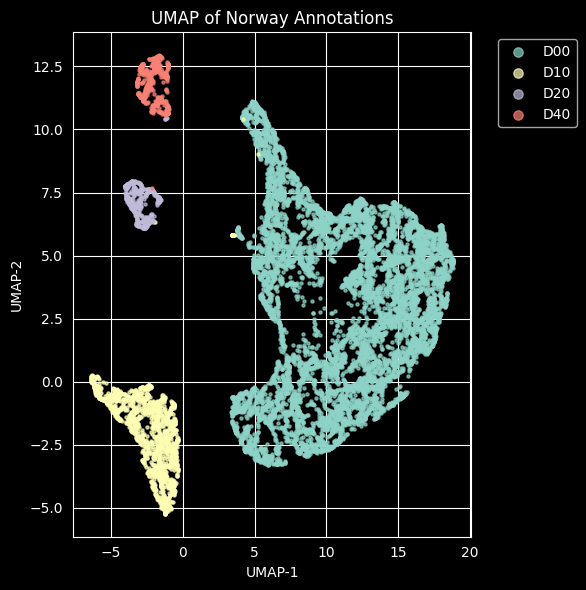

In [15]:
# Visualization for Norway
df = pd.DataFrame(all_norway_train_xmls)

df["box_w"] = df["xmax"] - df["xmin"]
df["box_h"] = df["ymax"] - df["ymin"]
df["range_xmin"] = df["xmin"] / df["width"]
df["range_ymin"] = df["ymin"] / df["height"]
df["range_box_w"] = df["box_w"] / df["width"]
df["range_box_h"] = df["box_h"] / df["height"]

class_convert_id = {c: i for i, c in enumerate(sorted(df["class"].unique()))}
df["class_id"] = df["class"].map(class_convert_id)

features = df[["range_xmin", "range_ymin", "range_box_w", "range_box_h", "class_id"]].values

scaled = StandardScaler().fit_transform(features)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2
)

embedding = reducer.fit_transform(scaled)
df["umap_x"] = embedding[:, 0]
df["umap_y"] = embedding[:, 1]

plt.figure(figsize=(6, 6))
for cls, sub in df.groupby("class"):
    plt.scatter(sub["umap_x"], sub["umap_y"], s=5, alpha=0.7, label=cls)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of Norway Annotations")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("")

In [ ]:
United States Exploration

In [16]:
#United States Train Directory - Processing XML Files
us_train_path = Path("/nfshome/data/United_States/train")

us_train_xml_dir = us_train_path / "annotations" / "xmls"
us_train_xml_files = sorted(us_train_xml_dir.glob("*.xml"))

all_us_train_xmls =[]

# Object Extraction: https://lxml.de/tutorial.html
for file in us_train_xml_files:
    tree = ET.parse(file)
    root = tree.getroot()
    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)
    depth_elem = root.find("size/depth")
    depth = int(depth_elem.text)if depth_elem is not None and depth_elem.text else None
    for obj in root.findall("object"):
        cls = obj.find("name").text
        pose = obj.findtext("pose", default="uknown")

        #truncated = int(obj.findtext("truncated",default="uknown"))
        truncated = int(root.find("truncated").text) if root.find("truncated") is not None else None,
        #difficult = int(obj.find("difficult").text)
        difficult = int(root.find("difficult").text) if root.find ("difficult") is not None else None,

        bnd = obj.find("bndbox")
        xmin = float(bnd.find("xmin").text)
        ymin = float(bnd.find("ymin").text)
        xmax = float(bnd.find("xmax").text)
        ymax = float(bnd.find("ymax").text)

        all_us_train_xmls.append(
            {
                "file": filename,
                "width": width,
                "height": height,
                "depth": depth,
                "class": cls,
                "pose": pose,
                "truncated": truncated,
                "difficult": difficult,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            }
        )

# United States Train Directory - Processing Image Files
us_train_image_dir = us_train_path / "images"
us_train_images = list(us_train_image_dir.glob("*.jpg"))

# United States Test Directory - Processing Image Files
us_test_path = Path("/nfshome/data/United_States/test")
us_test_image_dir = us_test_path / "images"
us_test_images = list(us_test_image_dir.glob("*.jpg"))

print(" "*20, "United States Overview")
print(f"Number of United States objects: {len(all_us_train_xmls)}")
print("\nAnnotation Example:")
us_train_xml_files = list({d["file"] for d in all_us_train_xmls})
rand_file = random.choice(us_train_xml_files)
us_train_objs = [d for d in all_us_train_xmls if d["file"] == rand_file]
for o in us_train_objs:
    print(o)

print(f"\nNumber of United States images in train directory: {len(us_train_images)}")
print(f"Number of United States images in test directory: {len(us_test_images)}")
print(f"Total United States images: {(len(us_train_images) + len(us_test_images))}")

                     United States Overview
Number of United States objects: 11014

Annotation Example:
{'file': 'United_States_003297.jpg', 'width': 640, 'height': 640, 'depth': 3, 'class': 'D10', 'pose': 'Unspecified', 'truncated': (None,), 'difficult': (None,), 'xmin': 109.0, 'ymin': 437.0, 'xmax': 448.0, 'ymax': 474.0}
{'file': 'United_States_003297.jpg', 'width': 640, 'height': 640, 'depth': 3, 'class': 'D10', 'pose': 'Unspecified', 'truncated': (None,), 'difficult': (None,), 'xmin': 418.0, 'ymin': 406.0, 'xmax': 640.0, 'ymax': 434.0}
{'file': 'United_States_003297.jpg', 'width': 640, 'height': 640, 'depth': 3, 'class': 'D00', 'pose': 'Unspecified', 'truncated': (None,), 'difficult': (None,), 'xmin': 401.0, 'ymin': 396.0, 'xmax': 587.0, 'ymax': 609.0}
{'file': 'United_States_003297.jpg', 'width': 640, 'height': 640, 'depth': 3, 'class': 'D10', 'pose': 'Unspecified', 'truncated': (None,), 'difficult': (None,), 'xmin': 1.0, 'ymin': 447.0, 'xmax': 125.0, 'ymax': 485.0}

Number of Uni

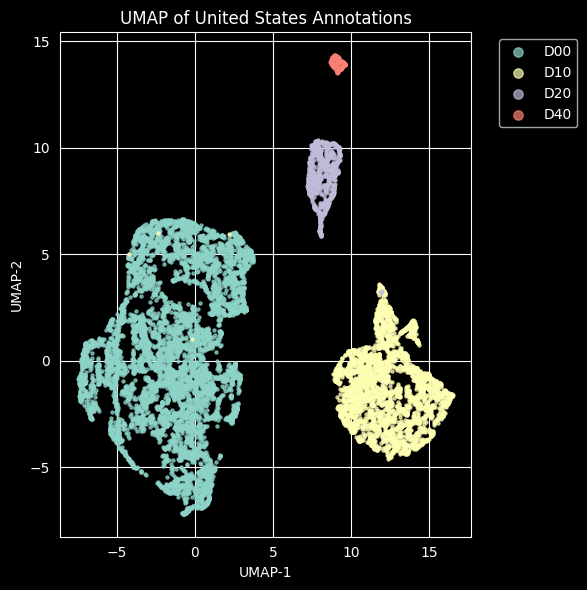

In [17]:
# Visualization for United States
df = pd.DataFrame(all_us_train_xmls)

df["box_w"] = df["xmax"] - df["xmin"]
df["box_h"] = df["ymax"] - df["ymin"]
df["range_xmin"] = df["xmin"] / df["width"]
df["range_ymin"] = df["ymin"] / df["height"]
df["range_box_w"] = df["box_w"] / df["width"]
df["range_box_h"] = df["box_h"] / df["height"]

class_convert_id = {c: i for i, c in enumerate(sorted(df["class"].unique()))}
df["class_id"] = df["class"].map(class_convert_id)

features = df[["range_xmin", "range_ymin", "range_box_w", "range_box_h", "class_id"]].values

scaled = StandardScaler().fit_transform(features)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2
)

embedding = reducer.fit_transform(scaled)
df["umap_x"] = embedding[:, 0]
df["umap_y"] = embedding[:, 1]

plt.figure(figsize=(6, 6))
for cls, sub in df.groupby("class"):
    plt.scatter(sub["umap_x"], sub["umap_y"], s=5, alpha=0.7, label=cls)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of United States Annotations")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("")

In [ ]:
# Statistical Overview

In [52]:
all_objs = (all_drone_xmls +
            all_mb_train_xmls +
            all_czech_train_xmls +
            all_india_train_xmls +
            all_japan_train_xmls +
            all_norway_train_xmls +
            all_us_train_xmls)

all_xmls = {
    'Chine_Drone': all_drone_xmls,
    'China_MotorBike': all_mb_train_xmls,
    'Czech': all_czech_train_xmls,
    'India': all_india_train_xmls,
    'Japan': all_japan_train_xmls,
    'Norway': all_norway_train_xmls,
    'United States': all_us_train_xmls}

all_train_images = (drone_images +
              mb_train_images +
              czech_train_images +
              india_train_images +
              japan_train_images +
              norway_train_images +
              us_train_images)

all_test_images = (drone_images +
              mb_test_images +
              czech_test_images +
              india_test_images +
              japan_test_images +
              norway_test_images +
              us_test_images)

filename_counts = Counter([ann['file'] for ann in all_objs])
multi_obj_files = {f: count for f, count in filename_counts.items() if count > 1}

print(f"Total number of objects in annotations: {len(all_objs)}")
print(f"Total number of train images: {len(all_train_images)}")
print(f"Total number of test images: {len(all_test_images)}")
print(f"Total number of images: {(len(all_train_images) + len(all_test_images))}")
print(f"Total images with multiple objects: {len(multi_obj_files)}")
print(f"Percentage of train images: {round(len(all_train_images)/(len(all_train_images)+len(all_test_images)), 4)*100}%")
print(f"Percentage of test images: {round(len(all_test_images)/(len(all_train_images)+len(all_test_images)), 4)*100}%")
print(f"Percentage of images with multiple objects: {round(len(multi_obj_files)/len(filename_counts), 4)*100}%")


Total number of objects in annotations: 65712
Total number of train images: 38385
Total number of test images: 11436
Total number of images: 49821
Total images with multiple objects: 16443
Percentage of train images: 77.05%
Percentage of test images: 22.95%
Percentage of images with multiple objects: 61.67%


In [ ]:
Overall Visualization

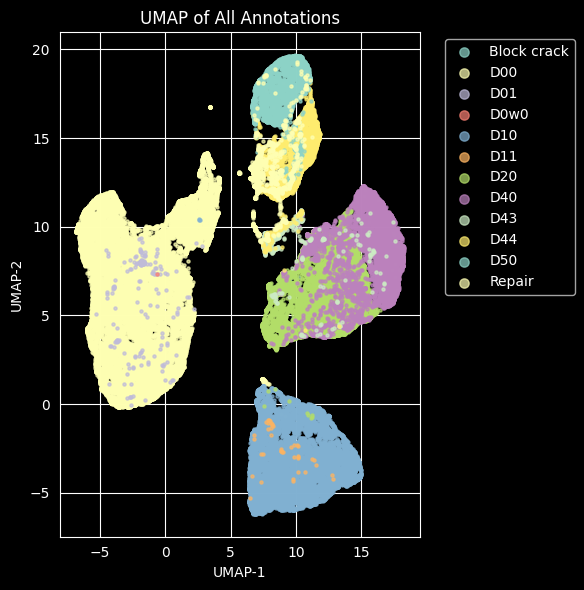

In [56]:
# Class Umap
df = pd.DataFrame(all_objs)

df["box_w"] = df["xmax"] - df["xmin"]
df["box_h"] = df["ymax"] - df["ymin"]
df["range_xmin"] = df["xmin"] / df["width"]
df["range_ymin"] = df["ymin"] / df["height"]
df["range_box_w"] = df["box_w"] / df["width"]
df["range_box_h"] = df["box_h"] / df["height"]

class_convert_id = {c: i for i, c in enumerate(sorted(df["class"].unique()))}
df["class_id"] = df["class"].map(class_convert_id)

features = df[["range_xmin", "range_ymin", "range_box_w", "range_box_h", "class_id"]].values

scaled = StandardScaler().fit_transform(features)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2
)

embedding = reducer.fit_transform(scaled)
df["umap_x"] = embedding[:, 0]
df["umap_y"] = embedding[:, 1]

plt.figure(figsize=(6, 6))
for cls, sub in df.groupby("class"):
    plt.scatter(sub["umap_x"], sub["umap_y"], s=5, alpha=0.7, label=cls)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of All Annotations")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("")

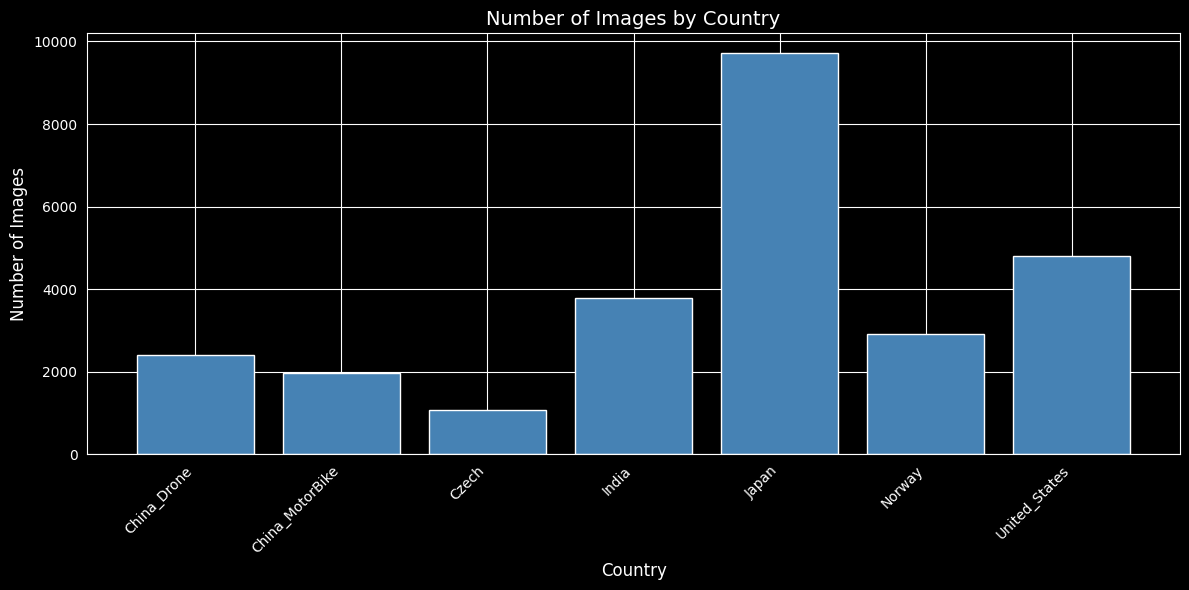

In [62]:
#Images per country
import matplotlib.pyplot as plt

# Count unique images per country
country_image_counts = {
    'China_Drone': len(set([ann['file'] for ann in all_drone_xmls])),
    'China_MotorBike': len(set([ann['file'] for ann in all_mb_train_xmls])),
    'Czech': len(set([ann['file'] for ann in all_czech_train_xmls])),
    'India': len(set([ann['file'] for ann in all_india_train_xmls])),
    'Japan': len(set([ann['file'] for ann in all_japan_train_xmls])),
    'Norway': len(set([ann['file'] for ann in all_norway_train_xmls])),
    'United_States': len(set([ann['file'] for ann in all_us_train_xmls]))
}

# Create bar plot
plt.figure(figsize=(12, 6))
plt.bar(country_image_counts.keys(), country_image_counts.values(), color='steelblue')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Number of Images by Country', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

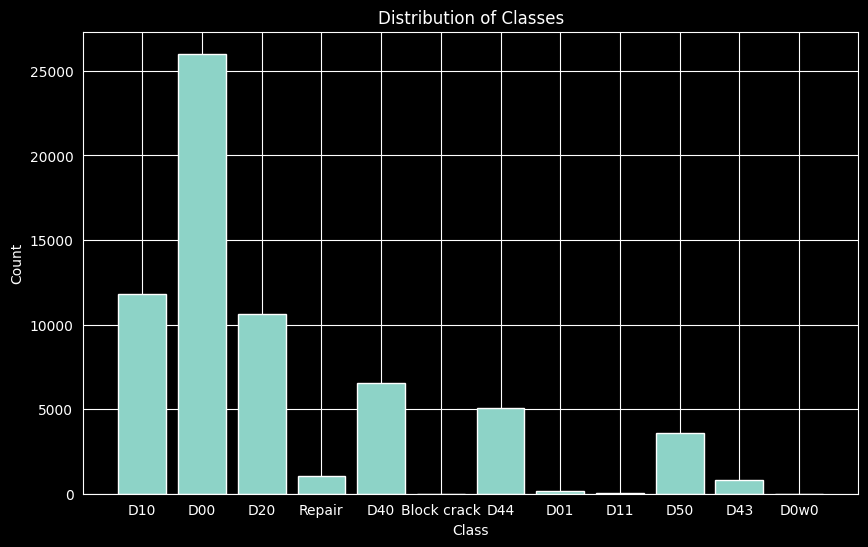

In [58]:
# Class Distribution
class_counts = Counter([ann['class'] for ann in all_objs])
plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of Classes')
plt.show()



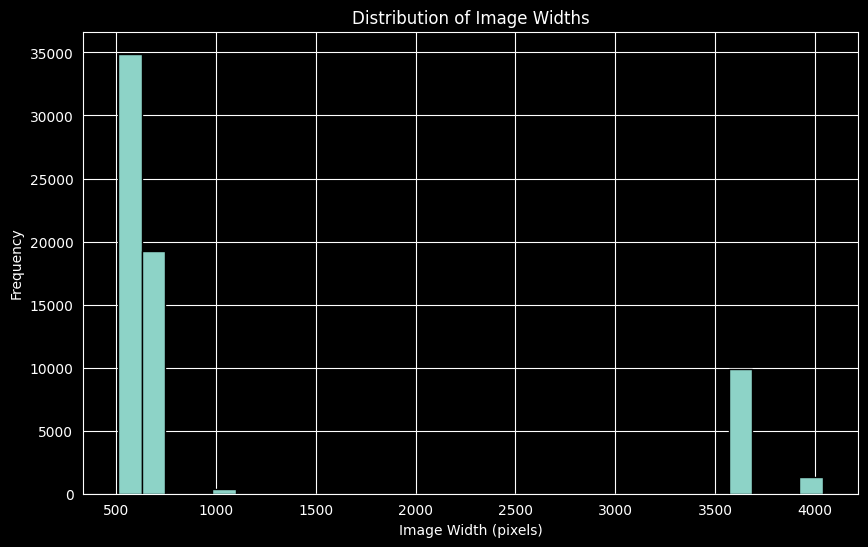

In [57]:
# Width Distribution
widths = [ann['width'] for ann in all_objs]

plt.figure(figsize=(10, 6))
plt.hist(widths, bins=30, edgecolor='black')
plt.xlabel('Image Width')
plt.ylabel('Frequency')
plt.title('Distribution of Image Widths')
plt.show()

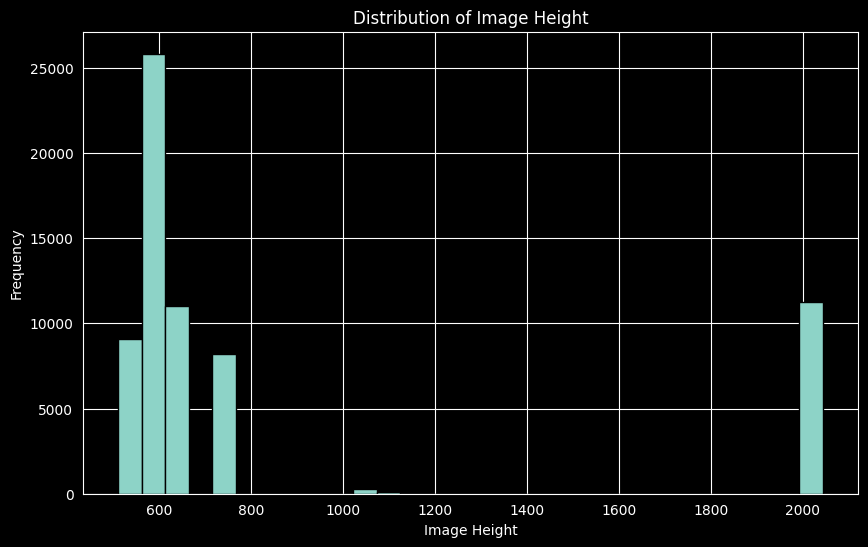

In [60]:
# Height Distribution
heighths = [ann['height'] for ann in all_objs]

plt.figure(figsize=(10, 6))
plt.hist(heighths, bins=30, edgecolor='black')
plt.xlabel('Image Height')
plt.ylabel('Frequency')
plt.title('Distribution of Image Height')
plt.show()

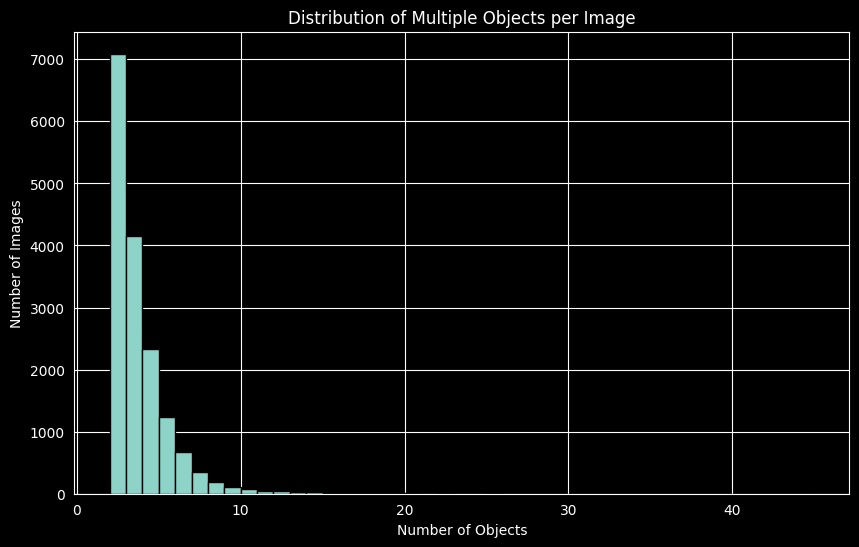

In [64]:
plt.figure(figsize=(10, 6))
plt.hist(multi_obj_files.values(), bins=range(2, max(multi_obj_files.values()) + 2), edgecolor='black')
plt.xlabel('Number of Objects')
plt.ylabel('Number of Images')
plt.title('Distribution of Multiple Objects per Image')
plt.show()